In [4]:
%pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 41.7 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 37.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]
Note: you may need to restart the kernel to use updated packages.


In [4]:
# Importamos pandas para trabajar con los datos
import pandas as pd

# Cargamos la base de datos
df = pd.read_csv("weekly_ae_activity_20260920.csv")

# Mostramos los primeros cinco registros
df.head()

,WeekEndingDate,Country,HBT,TreatmentLocation,DepartmentType,AttendanceCategory,NumberOfAttendancesEpisode,NumberWithin4HoursEpisode,NumberOver4HoursEpisode,PercentageWithin4HoursEpisode,NumberOver8HoursEpisode,PercentageOver8HoursEpisode,NumberOver12HoursEpisode,PercentageOver12HoursEpisode
0,20150222,S92000003,S08000015,A210H,Type 1,Unplanned,814,624,190,76.7,21,2.6,2,0.2
1,20150222,S92000003,S08000015,A210H,Type 1,All,814,624,190,76.7,21,2.6,2,0.2
2,20150222,S92000003,S08000015,A111H,Type 1,Unplanned,1347,1115,232,82.8,31,2.3,2,0.1
3,20150222,S92000003,S08000015,A111H,Type 1,All,1347,1115,232,82.8,31,2.3,2,0.1
4,20150222,S92000003,S08000016,B120H,Type 1,Unplanned,517,463,54,89.6,1,0.2,0,0.0


In [5]:
# Tamaño de la base
print("Filas y columnas:", df.shape)

# Valores faltantes por columna
print("\nValores faltantes:")
print(df.isna().sum())

# Registros duplicados
print("\nDuplicados:", df.duplicated().sum())

# Categorías de atención
print("\nCategorías:")
print(df["AttendanceCategory"].value_counts())

Filas y columnas: (42915, 14)

Valores faltantes:
WeekEndingDate                   0
Country                          0
HBT                              0
TreatmentLocation                0
DepartmentType                   0
AttendanceCategory               0
NumberOfAttendancesEpisode       0
NumberWithin4HoursEpisode        0
NumberOver4HoursEpisode          0
PercentageWithin4HoursEpisode    0
NumberOver8HoursEpisode          0
PercentageOver8HoursEpisode      0
NumberOver12HoursEpisode         0
PercentageOver12HoursEpisode     0
dtype: int64

Duplicados: 0

Categorías:
AttendanceCategory
Unplanned      18179
All            18179
New planned     6557
Name: count, dtype: int64


In [6]:
# Seleccionamos las atenciones no programadas
urgencias = df[df["AttendanceCategory"] == "Unplanned"].copy()

# Convertimos las fechas
urgencias["WeekEndingDate"] = pd.to_datetime(
    urgencias["WeekEndingDate"].astype(str),
    format="%Y%m%d"
)

# Calculamos el total semanal de las ubicaciones incluidas
demanda_semanal = (
    urgencias.groupby("WeekEndingDate")["NumberOfAttendancesEpisode"]
    .sum(min_count=1)
    .sort_index()
    .to_frame(name="Atenciones")
    .asfreq("W-SUN")
)

print("Número de semanas:", len(demanda_semanal))
print("Inicio:", demanda_semanal.index.min())
print("Fin:", demanda_semanal.index.max())
print("Semanas sin datos:", demanda_semanal["Atenciones"].isna().sum())

demanda_semanal.head()

Número de semanas: 605
Inicio: 2015-02-22 00:00:00
Fin: 2026-09-20 00:00:00
Semanas sin datos: 0


,Atenciones
WeekEndingDate,
2015-02-22,25513
2015-03-01,25401
2015-03-08,25151
2015-03-15,25238
2015-03-22,26247


In [7]:
print("Número de semanas:", len(demanda_semanal))
print("Inicio:", demanda_semanal.index.min())
print("Fin:", demanda_semanal.index.max())
print("Semanas sin datos:", demanda_semanal["Atenciones"].isna().sum())

Número de semanas: 605
Inicio: 2015-02-22 00:00:00
Fin: 2026-09-20 00:00:00
Semanas sin datos: 0


In [8]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


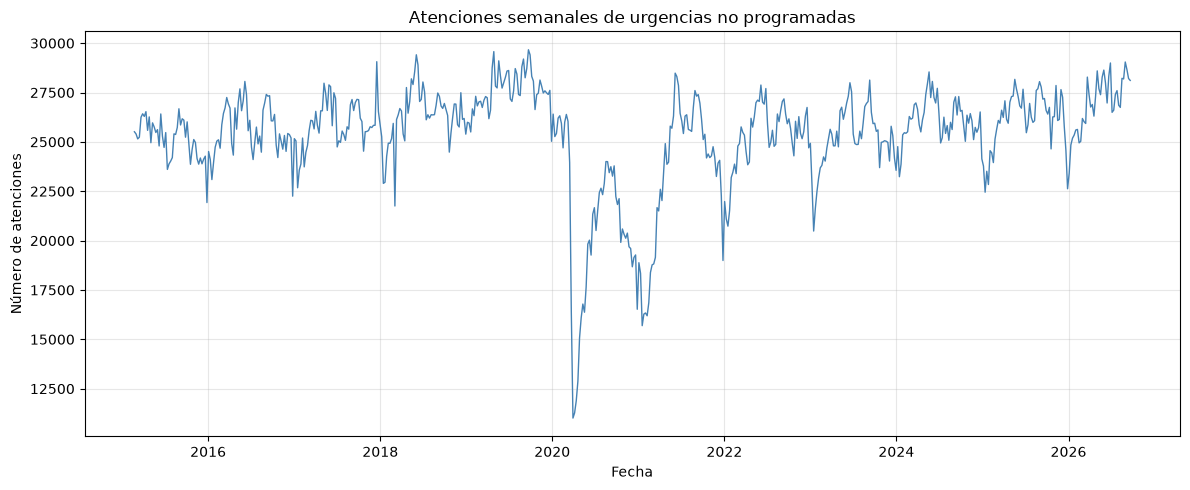

In [9]:
import matplotlib.pyplot as plt

# Graficamos las atenciones semanales
plt.figure(figsize=(12, 5))

plt.plot(
    demanda_semanal.index,
    demanda_semanal["Atenciones"],
    color="steelblue",
    linewidth=1
)

plt.title("Atenciones semanales de urgencias no programadas")
plt.xlabel("Fecha")
plt.ylabel("Número de atenciones")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Mínimo de hospitales por semana: 30
Máximo de hospitales por semana: 32


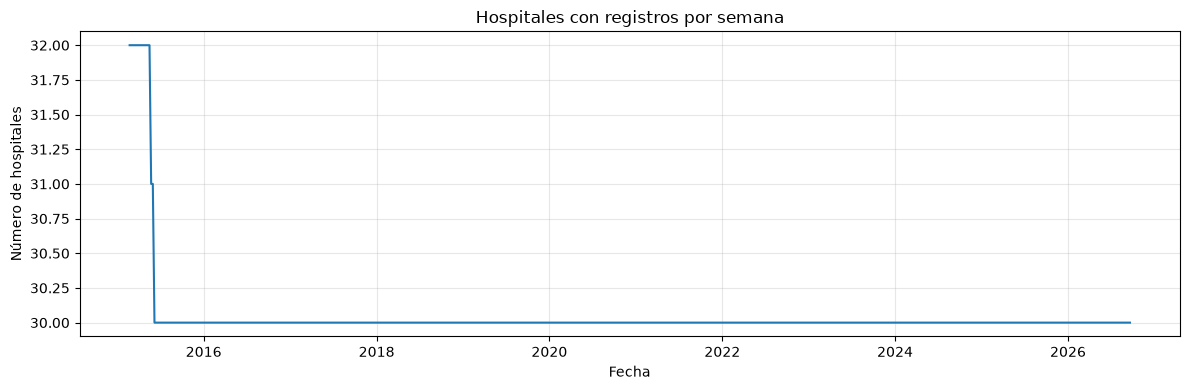

In [10]:
cobertura = (
    urgencias.groupby("WeekEndingDate")["TreatmentLocation"]
    .nunique()
    .sort_index()
)

print("Mínimo de hospitales por semana:", cobertura.min())
print("Máximo de hospitales por semana:", cobertura.max())

plt.figure(figsize=(12, 4))
plt.plot(cobertura.index, cobertura.values)
plt.title("Hospitales con registros por semana")
plt.xlabel("Fecha")
plt.ylabel("Número de hospitales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
### Demanda semanal y cobertura

La demanda presenta una caída pronunciada en 2020 y una recuperación posterior. El número de centros con registros disminuye de 32 a 30 al inicio de la serie y después permanece estable.

La caída de 2020 no coincide con una reducción del número de centros registrados. Sin embargo, este conteo no confirma que sean siempre los mismos centros ni permite determinar la causa del cambio en la demanda.

In [12]:

demanda = demanda_semanal["Atenciones"]

print("Resumen de atenciones semanales:")
print(demanda.describe().round(2))

cv = demanda.std() / demanda.mean() * 100
print("\nCoeficiente de variación:", round(cv, 2), "%")

print("\n5 semanas con mayor demanda:")
print(demanda.nlargest(5))

print("\n5 semanas con menor demanda:")
print(demanda.nsmallest(5))

Resumen de atenciones semanales:
count      605.00
mean     25355.38
std       2589.88
min      11012.00
25%      24739.00
50%      25856.00
75%      26913.00
max      29666.00
Name: Atenciones, dtype: float64

Coeficiente de variación: 10.21 %

5 semanas con mayor demanda:
WeekEndingDate
2019-09-22    29666
2019-04-28    29573
2018-06-03    29411
2019-09-29    29405
2019-09-01    29196
Name: Atenciones, dtype: int64

5 semanas con menor demanda:
WeekEndingDate
2020-03-29    11012
2020-04-05    11274
2020-04-12    11887
2020-04-19    12884
2020-04-26    15071
Freq: W-SUN, Name: Atenciones, dtype: int64


### Variación de la demanda semanal

En las 605 semanas analizadas, el promedio fue de 25,355.38 atenciones semanales, con una desviación estándar de 2,589.88 y un coeficiente de variación de 10.21%.

El 50% central de las semanas registró entre 24,739 y 26,913 atenciones. El máximo fue de 29,666 en la semana terminada el 22 de septiembre de 2019; el mínimo fue de 11,012 en la semana terminada el 29 de marzo de 2020.

Estos resultados describen toda la serie. El coeficiente de variación incluye cambios entre años y no representa el error de los futuros pronósticos.

In [13]:
resumen_anual = demanda.groupby(demanda.index.year).agg(
    ["count", "mean", "std", "min", "max"]
)

resumen_anual.columns = [
    "Semanas", "Promedio", "Desviación", "Mínimo", "Máximo"
]
resumen_anual.index.name = "Año"

display(resumen_anual.round(2))

,Semanas,Promedio,Desviación,Mínimo,Máximo
Año,,,,,
2015,45,25139.93,983.81,21927,26677
2016,52,25630.40,1248.15,22251,28062
2017,53,25910.47,1196.73,22676,29061
2018,52,26306.85,1427.37,21752,29411
2019,52,27625.29,1018.11,25030,29666
2020,52,20868.81,4021.38,11012,26406
2021,52,23436.38,3580.72,15692,28481
2022,52,25300.29,1607.18,20732,27879
2023,53,25179.87,1502.09,20484,28130


### Comparación por año

El promedio semanal pasó de 27,625.29 atenciones en 2019 a 20,868.81 en 2020. Además, 2020 presentó la mayor desviación estándar: 4,021.38 atenciones.

Después se observa una recuperación, aunque no es continua: el promedio fue de 25,300.29 en 2022, 25,179.87 en 2023 y 26,151.71 en 2025.

Los años 2015 y 2026 contienen 45 y 38 semanas, respectivamente. Sus promedios corresponden a periodos parciales y deben compararse con cautela.

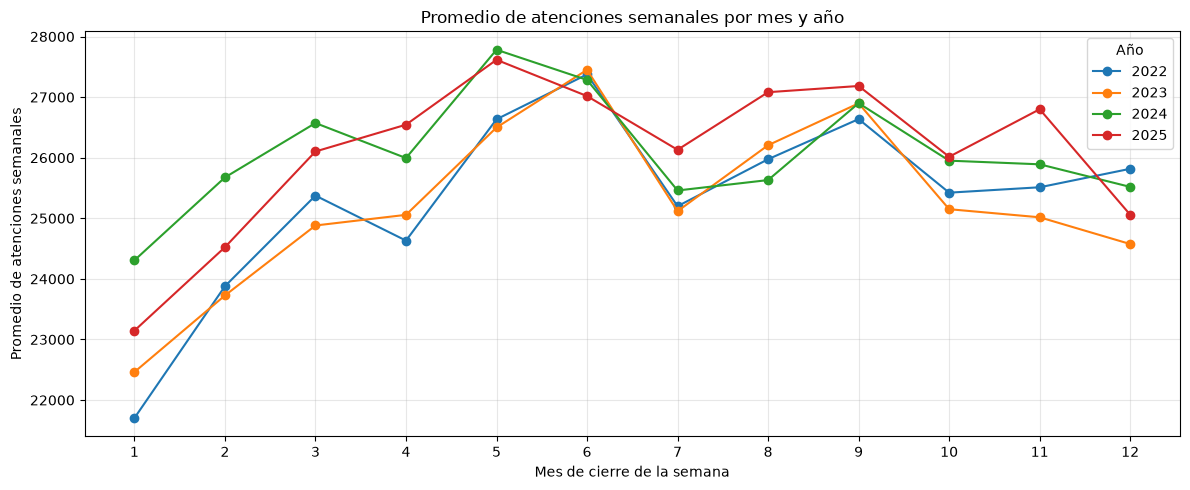

In [14]:
# Años completos recientes para explorar patrones mensuales
datos_mensuales = demanda_semanal.loc["2022":"2025"].copy()
datos_mensuales["Año"] = datos_mensuales.index.year
datos_mensuales["Mes"] = datos_mensuales.index.month

patron_mensual = datos_mensuales.pivot_table(
    index="Mes",
    columns="Año",
    values="Atenciones",
    aggfunc="mean"
)

patron_mensual.plot(figsize=(12, 5), marker="o")
plt.title("Promedio de atenciones semanales por mes y año")
plt.xlabel("Mes de cierre de la semana")
plt.ylabel("Promedio de atenciones semanales")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Exploración de patrones estacionales

Entre 2022 y 2025, enero presenta el menor promedio de atenciones semanales en cada año. La demanda aumenta hacia mayo y junio, disminuye en julio y vuelve a subir en septiembre.

La repetición de estos movimientos sugiere un patrón estacional anual, aunque su intensidad cambia entre años. Se compararán modelos con y sin estacionalidad para evaluar si incorporarla mejora los pronósticos.

### División para evaluar los pronósticos

Se reservan las últimas 52 semanas para prueba y las 52 anteriores para validación. El resto se utiliza como entrenamiento.

La validación permite comparar modelos y elegir sus parámetros. La prueba se reserva para evaluar el modelo seleccionado. Cada pronóstico estimará una semana usando únicamente información de semanas anteriores.

In [15]:
serie = demanda_semanal["Atenciones"].astype(float).copy()

assert serie.isna().sum() == 0, "Hay semanas sin datos."

train = serie.iloc[:-104]
valid = serie.iloc[-104:-52]
test = serie.iloc[-52:]

division = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación", "Prueba"],
    "Semanas": [len(train), len(valid), len(test)],
    "Inicio": [
        train.index.min(),
        valid.index.min(),
        test.index.min()
    ],
    "Fin": [
        train.index.max(),
        valid.index.max(),
        test.index.max()
    ]
})

display(division)

,Conjunto,Semanas,Inicio,Fin
0,Entrenamiento,501,2015-02-22,2024-09-22
1,Validación,52,2024-09-29,2025-09-21
2,Prueba,52,2025-09-28,2026-09-20


In [16]:
# Usamos entrenamiento y validación; la prueba queda reservada
historial = pd.concat([train, valid])

pred_valid = pd.DataFrame({
    "Real": valid,
    "Ingenuo": historial.shift(1).loc[valid.index],
    "Ingenuo estacional": historial.shift(52).loc[valid.index],
    "Promedio móvil 4": (
        historial.shift(1).rolling(4).mean().loc[valid.index]
    )
})

# Error = real - pronóstico
resultados = []

for modelo in pred_valid.columns.drop("Real"):
    error = pred_valid["Real"] - pred_valid[modelo]

    resultados.append({
        "Modelo": modelo,
        "MD": error.mean(),
        "MAD": error.abs().mean(),
        "MAPE (%)": (
            error.abs() / pred_valid["Real"]
        ).mean() * 100,
        "RMSE": (error.pow(2).mean()) ** 0.5
    })

metricas_valid = (
    pd.DataFrame(resultados)
    .set_index("Modelo")
    .sort_values("MAD")
)

display(metricas_valid.round(2))

,MD,MAD,MAPE (%),RMSE
Modelo,,,,
Ingenuo,-1.90,643.33,2.50,799.57
Promedio móvil 4,19.51,751.51,2.93,914.19
Ingenuo estacional,215.23,782.88,3.03,966.62


### Resultados de los modelos de referencia

El modelo ingenuo presentó los menores errores en validación: MAD de 643.33 atenciones, MAPE de 2.50% y RMSE de 799.57.

Su MD de −1.90 indica un sesgo promedio cercano a cero, aunque los errores positivos y negativos pueden cancelarse.

El promedio móvil de cuatro semanas y el ingenuo estacional obtuvieron errores mayores. Por ahora, utilizar la demanda de la semana anterior es la mejor referencia para evaluar los siguientes modelos.

Estos resultados corresponden a pronósticos de una semana adelante durante las 52 semanas de validación.